In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.columns = ['X',"Y","class"]
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


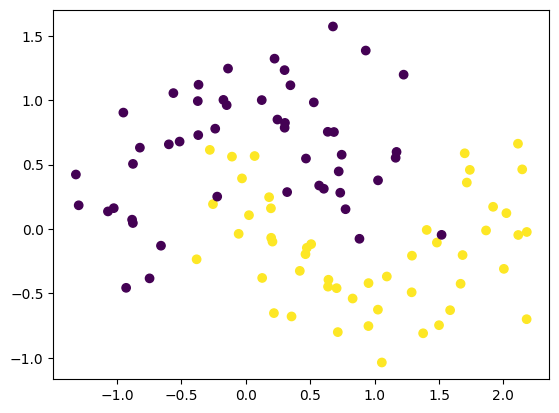

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# For Relu

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                30        
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [8]:
# Set parameters to 0
model.get_weights()

[array([[ 0.14604521, -0.41832164, -0.6867488 , -0.173087  , -0.16975218,
          0.01301378,  0.2896908 ,  0.14000052, -0.11650115,  0.01288784],
        [-0.00448811,  0.19872087,  0.07168859, -0.02468657,  0.25337452,
         -0.5676904 ,  0.20830101,  0.27567023, -0.10089618,  0.25442636]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.05014443],
        [-0.31216046],
        [ 0.5773911 ],
        [ 0.07107234],
        [ 0.11052024],
        [ 0.648331  ],
        [ 0.3746478 ],
        [ 0.03178275],
        [-0.28486535],
        [-0.6879118 ]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 2s 81ms/step - loss: 2.4808 - accuracy: 0.5063 - val_loss: 1.8241 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 18ms/step - loss: 2.4543 - accuracy: 0.5063 - val_loss: 1.8057 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 19ms/step - loss: 2.4269 - accuracy: 0.5063 - val_loss: 1.7874 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 17ms/step - loss: 2.4021 - accuracy: 0.5063 - val_loss: 1.7692 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 17ms/step - loss: 2.3772 - accuracy: 0.5063 - val_loss: 1.7515 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 17ms/step - loss: 2.3505 - accuracy: 0.5063 - val_loss: 1.7343 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 17ms/step - loss: 2.3245 - accuracy: 0.5063 - val_loss: 1.7170 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [14]:
model.get_weights()

[array([[0.31082726, 0.31082726, 0.31082726, 0.31082726, 0.31082726,
         0.31082726, 0.31082726, 0.31082726, 0.31082726, 0.31082726],
        [0.25203648, 0.25203648, 0.25203648, 0.25203648, 0.25203648,
         0.25203648, 0.25203648, 0.25203648, 0.25203648, 0.25203648]],
       dtype=float32),
 array([0.26851666, 0.26851666, 0.26851666, 0.26851666, 0.26851666,
        0.26851666, 0.26851666, 0.26851666, 0.26851666, 0.26851666],
       dtype=float32),
 array([[0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214],
        [0.26152214]], dtype=float32),
 array([0.229338], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

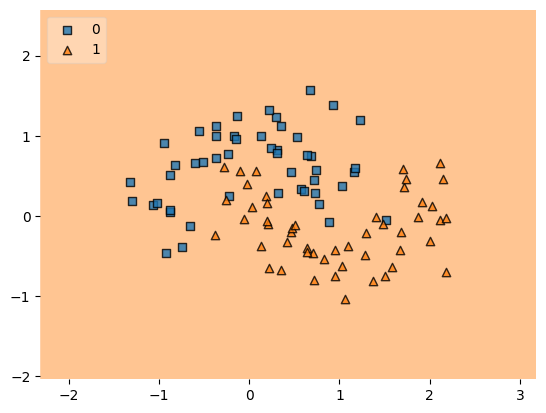

In [15]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# tanh

In [16]:
model1 = Sequential()

model1.add(Dense(10,activation='tanh',input_dim=2))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 10)                30        
                                                                 
 dense_3 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [17]:
model1.get_weights()

[array([[ 0.5230419 , -0.4768238 , -0.12717408,  0.22638589,  0.6836843 ,
          0.48675603, -0.00447327, -0.06238085, -0.24524829, -0.500774  ],
        [-0.04831952, -0.48314667, -0.5706368 ,  0.4829299 , -0.19736642,
         -0.03780723,  0.27414048,  0.18095732, -0.08195221,  0.28197116]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.4446631 ],
        [-0.62861717],
        [ 0.60243315],
        [ 0.54388386],
        [ 0.7291036 ],
        [-0.1893943 ],
        [-0.69911534],
        [-0.6874065 ],
        [ 0.31997627],
        [-0.10525197]], dtype=float32),
 array([0.], dtype=float32)]

In [18]:
initial_weights1 = model1.get_weights()

In [19]:
initial_weights1[0] = np.ones(model1.get_weights()[0].shape)*0.5
initial_weights1[1] = np.ones(model1.get_weights()[1].shape)*0.5
initial_weights1[2] = np.ones(model1.get_weights()[2].shape)*0.5
initial_weights1[3] = np.ones(model1.get_weights()[3].shape)*0.5

In [20]:
model1.set_weights(initial_weights1)

In [21]:
model1.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [22]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 1s 77ms/step - loss: 1.8839 - accuracy: 0.5063 - val_loss: 1.4461 - val_accuracy: 0.5500
Epoch 2/100
3/3 [==============================] - 0s 25ms/step - loss: 1.8691 - accuracy: 0.5063 - val_loss: 1.4316 - val_accuracy: 0.5500
Epoch 3/100
3/3 [==============================] - 0s 22ms/step - loss: 1.8537 - accuracy: 0.5063 - val_loss: 1.4176 - val_accuracy: 0.5500
Epoch 4/100
3/3 [==============================] - 0s 21ms/step - loss: 1.8396 - accuracy: 0.5063 - val_loss: 1.4039 - val_accuracy: 0.5500
Epoch 5/100
3/3 [==============================] - 0s 18ms/step - loss: 1.8245 - accuracy: 0.5063 - val_loss: 1.3903 - val_accuracy: 0.5500
Epoch 6/100
3/3 [==============================] - 0s 19ms/step - loss: 1.8106 - accuracy: 0.5063 - val_loss: 1.3777 - val_accuracy: 0.5500
Epoch 7/100
3/3 [==============================] - 0s 20ms/step - loss: 1.7947 - accuracy: 0.5063 - val_loss: 1.3645 - val_accuracy: 0.5500
Epoch 8/100
3/3 [===

In [23]:
model1.get_weights()

[array([[0.5268502, 0.5268502, 0.5268502, 0.5268502, 0.5268502, 0.5268502,
         0.5268502, 0.5268502, 0.5268502, 0.5268502],
        [0.2257127, 0.2257127, 0.2257127, 0.2257127, 0.2257127, 0.2257127,
         0.2257127, 0.2257127, 0.2257127, 0.2257127]], dtype=float32),
 array([0.25141016, 0.25141016, 0.25141016, 0.25141016, 0.25141016,
        0.25141016, 0.25141016, 0.25141016, 0.25141016, 0.25141016],
       dtype=float32),
 array([[0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211],
        [0.2534211]], dtype=float32),
 array([0.2327529], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

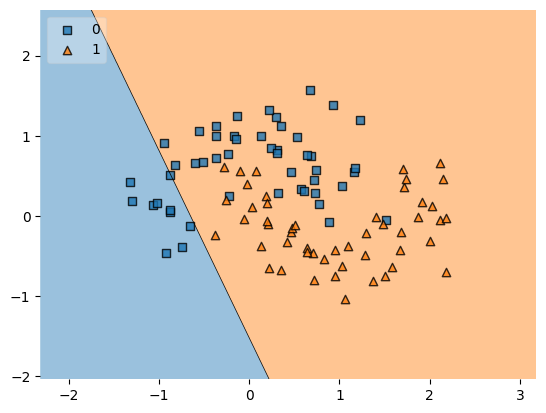

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model1, legend=2)

# Sigmoid

In [25]:
model2 = Sequential()

model2.add(Dense(10,activation='sigmoid',input_dim=2))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 10)                30        
                                                                 
 dense_5 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [26]:
model2.get_weights()

[array([[ 0.34462756, -0.5055804 ,  0.4187122 ,  0.283391  ,  0.5216902 ,
          0.21937555, -0.0070591 , -0.48751512,  0.16231275,  0.25750107],
        [ 0.46335572,  0.36845857, -0.38880298,  0.3217917 ,  0.0906238 ,
         -0.5391222 ,  0.31657892,  0.1820823 , -0.03223896,  0.46220487]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.19475746],
        [-0.46728376],
        [-0.49599457],
        [-0.35475108],
        [ 0.0678463 ],
        [ 0.38288766],
        [-0.50768125],
        [ 0.18209618],
        [ 0.12794405],
        [ 0.36535877]], dtype=float32),
 array([0.], dtype=float32)]

In [27]:
new_Weights = model2.get_weights()

In [28]:
new_Weights[0] = np.ones(model2.get_weights()[0].shape)*0.5
new_Weights[1] = np.ones(model2.get_weights()[1].shape)*0.5
new_Weights[2] = np.ones(model2.get_weights()[2].shape)*0.5
new_Weights[3] = np.ones(model2.get_weights()[3].shape)*0.5

In [29]:
model2.set_weights(new_Weights)

In [30]:
model2.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [31]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 0s 68ms/step - loss: 1.9925 - accuracy: 0.5063 - val_loss: 1.8419 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 22ms/step - loss: 1.9783 - accuracy: 0.5063 - val_loss: 1.8294 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 22ms/step - loss: 1.9645 - accuracy: 0.5063 - val_loss: 1.8169 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 19ms/step - loss: 1.9521 - accuracy: 0.5063 - val_loss: 1.8045 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 19ms/step - loss: 1.9380 - accuracy: 0.5063 - val_loss: 1.7921 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 21ms/step - loss: 1.9252 - accuracy: 0.5063 - val_loss: 1.7798 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 19ms/step - loss: 1.9114 - accuracy: 0.5063 - val_loss: 1.7676 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [32]:
model2.get_weights()

[array([[0.4399787, 0.4399787, 0.4399787, 0.4399787, 0.4399787, 0.4399787,
         0.4399787, 0.4399787, 0.4399787, 0.4399787],
        [0.2465409, 0.2465409, 0.2465409, 0.2465409, 0.2465409, 0.2465409,
         0.2465409, 0.2465409, 0.2465409, 0.2465409]], dtype=float32),
 array([0.25809106, 0.25809106, 0.25809106, 0.25809106, 0.25809106,
        0.25809106, 0.25809106, 0.25809106, 0.25809106, 0.25809106],
       dtype=float32),
 array([[0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065],
        [0.23166065]], dtype=float32),
 array([0.22361149], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

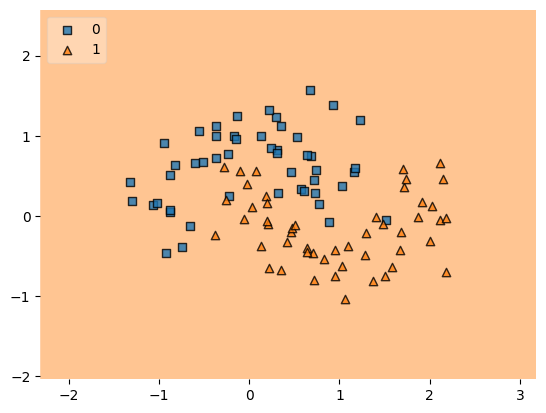

In [33]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)